Attempting to replicate the results from Gelli+24

In [1]:
from escripts import eMCMC
import importlib
from escripts import eplots
Plotting = eplots.Plotting()
import time

In [2]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt',
                       '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt', 
                      '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']

In [3]:
eMCMC.get_default_dict()

,fit,value,start,lower,upper,label
alpha,True,0.6,0.6,0,4,$\alpha$
dalphadz,True,0,0.01,-0.5,0.5,$d\alpha/dz$
beta,True,-0.5,-0.5,-1,0,$\beta$
dbetadz,True,0,0.01,-0.5,0.5,$d\beta/dz$
logMc,True,12,12,9,16,$\log(M_c)$
dlogMcdz,True,0,0.01,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-1,-1,1,$\log(\epsilon_0)$
dlogedz,True,0,0.01,-0.5,0.5,$d\log(\epsilon_0)/dz$
sig,True,0,0.5,0,6,"$\sigma_{\rm{UV}, 10}$"
dsigdz,True,0,0.01,-0.5,0.5,$d\sigma_{\rm{UV}}/dz$


In [4]:
custom_params = {'dalphadz': {'fit':False, 'value':0},
                'dbetadz': {'fit':False, 'value':0},
                'dlogMcdz': {'fit':False, 'value':0},
                'dlogedz': {'fit':False, 'value':0},
                'dsigdz': {'fit':False, 'value':0}}

In [5]:
param_data = eMCMC.build_param_data(custom_params)

In [6]:
my_UVLF = eMCMC.UVLF(file_names, data_labels, param_data)

In [7]:
ICs = my_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [8]:
# Run MCMC
t = time.time()
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 

State([[ 7.04049215e-01 -7.52745370e-01  1.21029104e+01 -7.91949080e-01
   4.69502444e-01 -1.42750793e-01]
 [ 6.53842385e-01 -8.33475687e-01  1.21595658e+01 -7.99582835e-01
   3.78518579e-01 -8.86695266e-02]
 [ 7.22844046e-01 -7.59991484e-01  1.20743935e+01 -8.11698128e-01
   5.24576360e-01 -1.63871400e-01]
 [ 7.02922668e-01 -6.16041268e-01  1.20785060e+01 -8.04048521e-01
   5.28827078e-01 -1.50427277e-01]
 [ 6.75078287e-01 -9.47644769e-01  1.21420497e+01 -8.20035068e-01
   4.05772747e-01 -8.49320574e-02]
 [ 7.05079567e-01 -7.75267381e-01  1.20184898e+01 -8.40466027e-01
   3.74929827e-01 -8.69907628e-03]
 [ 6.94509064e-01 -2.84851712e-01  1.18955294e+01 -8.93768667e-01
   3.97268569e-01 -1.03260459e-01]
 [ 6.78212499e-01 -6.00146027e-01  1.19760047e+01 -8.53288712e-01
   3.02408692e-01  3.02150419e-02]
 [ 6.39548155e-01 -8.29161070e-01  1.21862440e+01 -8.01491451e-01
   3.63006874e-01 -7.08013232e-02]
 [ 7.53567326e-01 -4.89180071e-01  1.19337202e+01 -8.31600761e-01
   3.63337752e-01 -

In [19]:
samples, best_fit, labels = my_UVLF.get_fit(excluded_params=['dalphadz', 'dbetadz', 'dlogMcdz', 'dlogedz', 'dsigdz'])

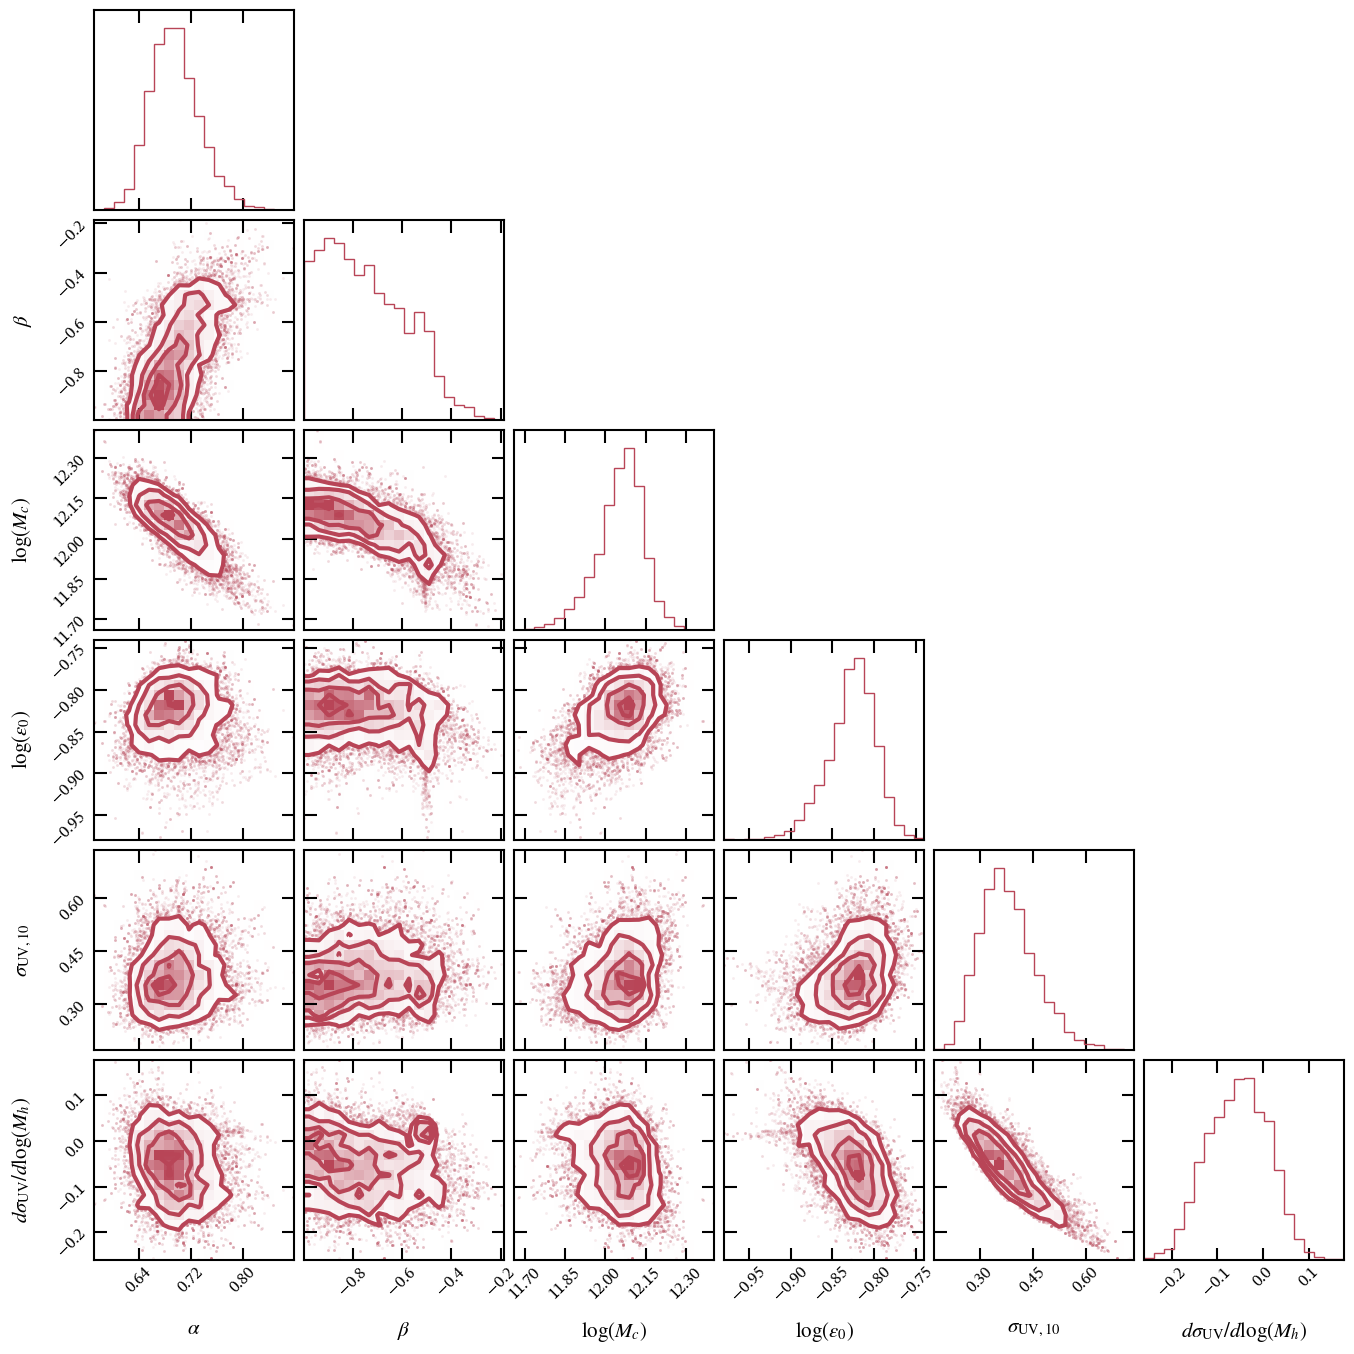

In [20]:
corner = Plotting.plot_corner(samples, my_UVLF)

In [41]:
def get_UVLF_data(best_fit, my_UVLF, zs):
    plot_xdat, plot_xerr = my_UVLF.data[0][2], my_UVLF.data[0][5]

    final_zs = []
    final_MUVs = []
    final_phis = []
    for i, (zbin, z) in enumerate(zip(my_UVLF.sorted_data, zs)):
        zdat, zerr = zbin[0][0], zbin[0][1]
        phi_UV = np.log10(my_UVLF.UVLF_wrapper(zdat,zerr, plot_xdat, plot_xerr, best_fit))
        final_zs.append(np.full_like(phi_UV, z))
        final_MUVs.append(plot_xdat)
        final_phis.append(phi_UV)

    return np.concatenate(final_zs), np.concatenate(final_MUVs), np.concatenate(final_phis)

In [42]:
zs, MUVs, phis = get_UVLF_data(best_fit, my_UVLF, [10, 11, 12, 13, 14])

array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 11.,
       11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 13., 13., 13.,
       13., 13., 13., 13., 13., 13., 13., 13., 13., 14., 14., 14., 14.,
       14., 14., 14., 14., 14., 14., 14., 14.])

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:150: RuntimeWarning: invalid value encountered in log10
  ax[i].plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,plot_xdat, plot_xerr,sample)), alpha=nsamples/3500, color = self.red,


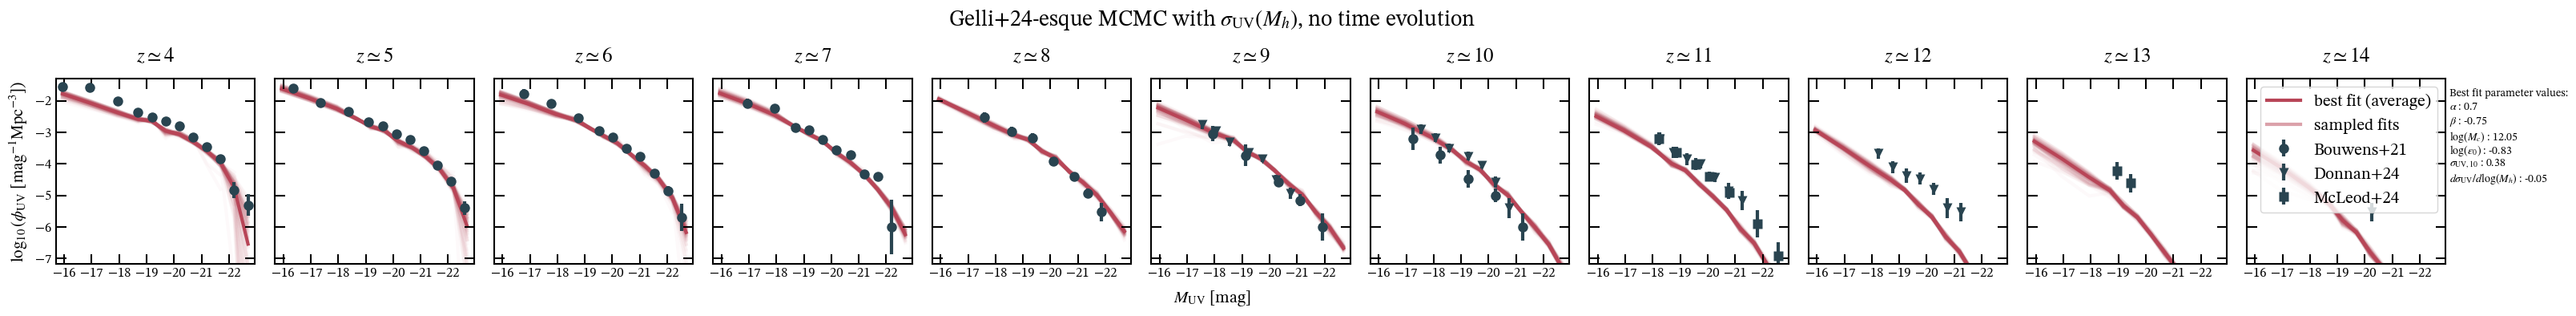

In [11]:
te_plot = Plotting.plot_evolving_UVLF_fit(samples, my_UVLF, title = r'Gelli+24-esque MCMC with $\sigma_{\rm{UV}}(M_h)$, no time evolution')
#te_plot.savefig('/Users/eb35267/Desktop/code/figures/Gelli_comparison/no_time_evolution_with_jwst_data.png', bbox_inches='tight')

# Testing with vs. without dust

In [12]:
np.savetxt('test.txt', [1, 2])

In [13]:
np.savetxt('test.txt', [5, 6])

TypeError: write() argument must be str, not list